### 1. 神经网络基本模型

例 17.3 采用单一感知器神经元解决简单的分类问题：将四个输入矢量分为两类，其中两个矢量对应的目标值为 $1$，另外两个矢量对应的目标值为 $0$，即输入矢量  
$$
\boldsymbol{P} = \begin{bmatrix} 
-0.5 & -0.5 & 0.3 & 0.0 \\
-0.5 & 0.5 & -0.5 & 1.0 
\end{bmatrix},
$$  
其中，每一列是一个输入的取值，且目标分类矢量 $\boldsymbol{T} = [1, 1, 0, 0]$. 试预测新输入矢量 $\boldsymbol{p} = [-0.5, 0.2]^{\mathrm{T}}$ 的目标值.  

记两个指标变量分别为 $x_1, x_2$，求得的分类函数为 $v = -1.3x_1 - 0.5x_2$. 新输入矢量 $\boldsymbol{p}$ 的目标值为 $1$.  

In [ ]:
import numpy as np
from sklearn.linear_model import Perceptron  # 感知器

x0 = np.array([[-0.5, -0.5, 0.3, 0.0], [-0.5, 0.5, -0.5, 1.0]]).T  # 输入向量,转置每一行是一个输入矢量
y0 = np.array([1, 1, 0, 0])  # 目标分类向量
model = Perceptron(tol=1e-3)  # 构造模型
model.fit(x0, y0)  # 拟合模型
coef = model.coef_[0]
x1_coef = coef[0]
x2_coef = coef[1]
p_pred = model.predict(np.array([[-0.5, 0.2]]))  # 预测

print(model.coef_, model.intercept_)  # 输出系数和常数项
print(f"分类函数为:v = ({x1_coef}) x1 + ({x2_coef}) x2 + {model.intercept_}")
print(model.score(x0, y0))  # 模型检验
print(f"预测值为:{p_pred}")

[[-1.3 -0.5]] [0.]
分类函数为:v = (-1.3) x1 + (-0.5) x2 + [0.]
1.0
预测值为:[1]


例 17.4 1981 年生物学家格若根 (W. Grogan) 和维什 (W. Wirth) 发现了两类飞蠓. 他们测量了这两类飞蠓每个个体的触角长和翼长, 数据见表 17.3. 抓到三只新的飞蠓, 它们的触角长和翼长分别为 $(1.24, 1.80)$, $(1.28, 1.84)$, $(1.40, 2.04)$, 试分别判定它们属于哪一个种类?  

将问题视为一个系统, 飞蠓的数据作为输入, 飞蠓的类型作为输出, 研究输入和输出的关系. 输入数据有 15 个, 对应 15 个输出.  

表 17.3 两种飞蠓的特征数据  

| 类别 |  | 触角长/cm | 翼长/cm | 类别 |  | 触角长/cm | 翼长/cm |
| ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- |
| Apf |  | 1.14 | 1.78 | Af |  | 1.24 | 1.72 |
| Apf |  | 1.18 | 1.96 | Af |  | 1.36 | 1.74 |
| Apf |  | 1.20 | 1.86 | Af |  | 1.38 | 1.64 |
| Apf |  | 1.26 | 2.00 | Af |  | 1.38 | 1.82 |
| Apf |  | 1.28 | 2.00 | Af |  | 1.38 | 1.90 |
| Apf |  | 1.30 | 1.96 | Af |  | 1.40 | 1.70 |
|  |  |  |  | Af |  | 1.48 | 1.82 |
|  |  |  |  | Af |  | 1.54 | 1.82 |
|  |  |  |  | Af |  | 1.56 | 2.08 |  


建立只有一个隐层, 神经元的个数为 15 的 BP 神经网络, 利用 Python 程序, 求得三只待判蠓虫分别属于 Apf, Af, Apf 类.  

In [ ]:
import numpy as np
from sklearn.neural_network import MLPClassifier

x0 = np.array([[1.14, 1.18, 1.20, 1.26, 1.28, 1.30, 1.24, 1.36,
                1.38, 1.38, 1.38, 1.40, 1.48, 1.54, 1.56],
               [1.78, 1.96, 1.86, 2.00, 2.00, 1.96, 1.72, 1.74,
                1.64, 1.82, 1.90, 1.70, 1.82, 1.82, 2.08]]).T  # 注意转置，一行是一个样品
y0 = np.r_[np.ones(6), np.zeros(9)]  # 前6个为1，是第一类，后九个为0，是第二类
# L-BFGS 的全称是 Limited-memory Broyden–Fletcher–Goldfarb–Shanno algorithm（有限内存BFGS算法）
model = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=15)
model.fit(x0, y0)
x = np.array([[1.24, 1.80], [1.28, 1.84], [1.40, 2.04]])
pred = model.predict(x)

print(model.score(x0, y0))
print()
print(model.coefs_[0])  # 隐藏层的权重矩阵, (2, 15)  输入层2个神经元，隐藏层15个神经元
print()
print(model.coefs_[1])  # 输出层的权重矩阵, (15, 1)  隐藏层15个神经元，输出层1个
print()
print(model.intercepts_[0])  # (15,)，隐藏层15个神经元的偏置项(bias)
print()
print(model.intercepts_[1])  # (1,)，输出层神经元的偏置项
print()
print(f"属于各类的概率为:\n{model.predict_proba(x)}")
print(f"三个待判样本点的类别为: {pred}")

1.0

[[-0.20209219 -0.15476685  0.43231145 -0.19055618  0.32267825 -0.39649058
  -9.65110138 -0.58478352 -7.58564562  8.71472371  0.23159296 -1.44005243
   6.58640044 -1.1531786  -4.00959698]
 [ 0.1149921  -0.15062163 -0.40493395  0.01292253 -0.49773849 -0.15659172
   2.97695957 -0.37662097  5.49972646 -4.48235547  0.86509624 -1.40015514
  -0.90346847  1.66084553  2.84789312]]

[[ 0.25280261]
 [ 0.45055692]
 [-0.52027458]
 [-0.55695851]
 [-0.31481095]
 [ 0.48575561]
 [ 1.25902926]
 [-0.20367961]
 [19.09904877]
 [ 4.5404753 ]
 [-3.81660232]
 [-0.34111859]
 [-4.50576999]
 [ 9.37781966]
 [ 3.35326165]]

[-0.64057432  0.28826535 -0.45549734 -0.40874763 -0.44342186  0.07249383
 -1.7120237   0.34674065  0.3504117   0.41936582  0.34804662 -0.23499451
  1.20834465  0.42733546  0.05111545]

[-6.08810917]

属于各类的概率为:
[[0.40128126 0.59871874]
 [0.82946027 0.17053973]
 [0.21100129 0.78899871]]
三个待判样本点的类别为: [1. 0. 1.]


例 17.5 公路运量主要包括客运量和货运量两个方面. 据研究, 某地区的公路运量主要与该地区的人数、机动车数量和公路面积有关, 表 17.4 给出了该地区 1990 年至 2009 年 20 年间公路运量的相关数据. 根据有关部门数据, 该地区 2010 年和 2011 年的人数分别为 73.39 万人、75.55 万人, 机动车数量分别为 3.9635 万辆、4.0975 万辆, 公路面积将分别为 0.9880 万平方米、1.0268 万平方米. 请利用 BP 神经网络预测该地区 2010 年和 2011 年的公路客运量和货运量.  

利用 BP 神经网络求得 2010 年和 2011 年的公路客运量的预测值分别为 $62782.0336$ 万人和 $65849.9027$ 万人; 货运量分别为 $31439.9231$ 万吨和 $32917.5961$ 万吨.  

原始数据和网络输出值的对比如图 17.5 所示.  


### 表 17.4 某地区的公路运量的相关数据  

| 年份 | 人口数量/万人 | 机动车数量/万辆 | 公路面积/万平方千米 | 客运量/万人 | 货运量/万吨 |
| ---- | ---- | ---- | ---- | ---- | ---- |
| 1990 | 20.55 | 0.6 | 0.09 | 5126 | 1237 |
| 1991 | 22.44 | 0.75 | 0.11 | 6217 | 1379 |
| 1992 | 25.37 | 0.85 | 0.11 | 7730 | 1385 |
| 1993 | 27.13 | 0.9 | 0.14 | 9145 | 1399 |
| 1994 | 29.45 | 1.05 | 0.2 | 10460 | 1663 |
| 1995 | 30.1 | 1.35 | 0.23 | 11387 | 1714 |
| 1996 | 30.96 | 1.45 | 0.23 | 12353 | 1834 |
| 1997 | 34.06 | 1.6 | 0.32 | 15750 | 4322 |
| 1998 | 36.42 | 1.7 | 0.32 | 18304 | 8132 |
| 1999 | 38.09 | 1.85 | 0.34 | 19836 | 8936 |
| 2000 | 39.13 | 2.15 | 0.36 | 21024 | 11099 |
| 2001 | 39.99 | 2.2 | 0.36 | 19490 | 11203 |
| 2002 | 41.93 | 2.25 | 0.38 | 20433 | 10524 |
| 2003 | 44.59 | 2.35 | 0.49 | 22598 | 11115 |
| 2004 | 47.3 | 2.5 | 0.56 | 25107 | 13320 |
| 2005 | 52.89 | 2.6 | 0.59 | 33442 | 16762 |
| 2006 | 55.73 | 2.7 | 0.59 | 36836 | 18673 |
| 2007 | 56.76 | 2.85 | 0.67 | 40548 | 20724 |
| 2008 | 59.17 | 2.95 | 0.69 | 42927 | 20803 |
| 2009 | 60.63 | 3.1 | 0.79 | 43462 | 21804 |  


### 图 17.5 客运量和货运量原始数据和网络输出值的对比图  
(a) 客运量对比图  
(b) 货运量对比图  

0.9946012393975541
客运量的预测值为: [61808.14005345 64790.24689578]
---------------------------------
0.9602455651425102
货运量的预测值为: [28910.32858154 30159.55605678]


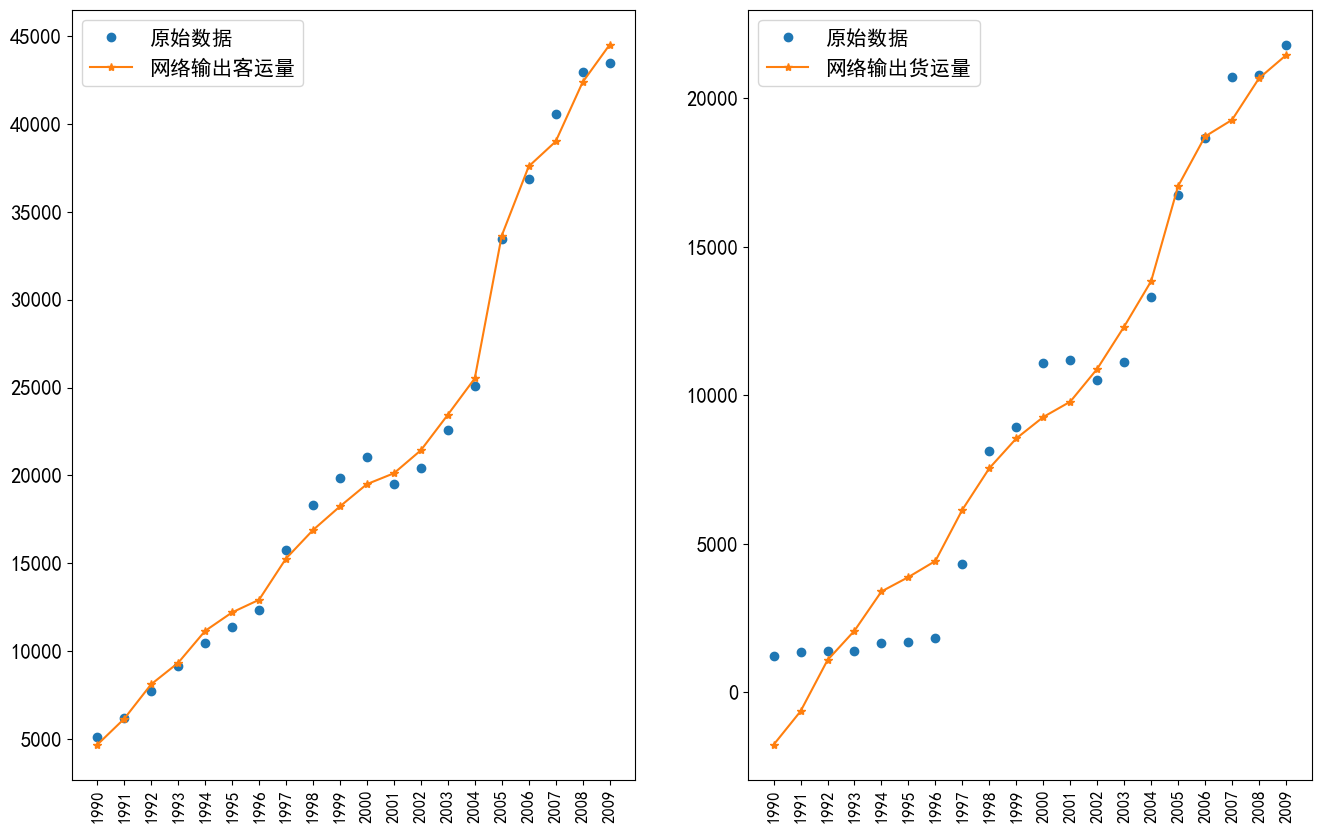

In [57]:
# 运行结果不稳定
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

plt.rcParams['font.size'] = 15
plt.rcParams['font.sans-serif'] = ['SimHei']
a = np.loadtxt("Pdata17_5.txt")
x0 = a[:, :3]  # (20, 3)
y1 = a[:, 3]
y2 = a[:, 4]

model1 = MLPRegressor(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=10)
model1.fit(x0, y1)
x = np.array([[73.39, 3.9635, 0.988], [75.55, 4.0975, 1.0268]])  # (2, 3)
pred1 = model1.predict(x)
print(model1.score(x0, y1))
print(f"客运量的预测值为: {pred1}")
print('---------------------------------')

model2 = MLPRegressor(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=10)
model2.fit(x0, y2)
pred2 = model2.predict(x)
print(model2.score(x0, y2))
print(f"货运量的预测值为: {pred2}")

yr = np.arange(1990, 2010)
plt.figure(figsize=(16, 10))
plt.subplot(121)
plt.plot(yr, y1, 'o')
plt.plot(yr, model1.predict(x0), '*-')
plt.xticks(yr, rotation=90, fontsize=12)
plt.legend(("原始数据", "网络输出客运量"))
plt.subplot(122)
plt.plot(yr, y2, 'o')
plt.plot(yr, model2.predict(x0), '-*')
plt.xticks(yr, rotation=90, fontsize=12)
plt.legend(("原始数据", "网络输出货运量"), loc='upper left')
plt.show()